In [1]:
import os
import sys
import copy
import torch
import argparse
from pprint import pprint


# Import ssu packages
sys.path.append('../src')
sys.path.append('../config')
# config packages
import read_config
# src packages
from eval import ABC_eval
from models import unet
from models import model as simpleModels
from models import unet as unetModels
from training import model_training_v2 as model_training
from logger import wandb_logging
from data_loader import ABC_dataset_loader
from utils import fvdb_utils as fu
from utils import ssu_tools as st 

import torch
import gc

def clear_gpu_memory():
    """Clear all GPU memory allocated by PyTorch"""
    
    if torch.cuda.is_available():
        # Clear PyTorch cache
        torch.cuda.empty_cache()
        
        # Force garbage collection
        gc.collect()
        
        # Clear all tensors from GPU
        torch.cuda.synchronize()
        
        # Get memory info
        allocated = torch.cuda.memory_allocated() / 1e9
        cached = torch.cuda.memory_reserved() / 1e9
        
        print(f"GPU Memory - Allocated: {allocated:.2f} GB, Cached: {cached:.2f} GB")
        
        # If memory is still allocated, try more aggressive clearing
        if allocated > 0:
            print("Attempting to clear more GPU memory...")
            print("Avoiding this step")
            # torch.cuda.empty_cache()
            # torch.cuda.synchronize()
            # gc.collect()
            
        print("✅ GPU memory cleared")
    else:
        print("❌ No CUDA GPU available")

# Call this function
clear_gpu_memory()

# def main(config_file):
config_file = 'config_55_10102025_1400.yaml'
# read config file
config = read_config.read_yaml_config(f'{config_file}')

print("Configuration loaded:")
for key, value in config.items():
    pprint(f"{key}: {value}")

# initialize logging
logger = wandb_logging.WandbLogger(
                    logging=config['logging'],
                    project_name=config['wandb']['project_name'],
                    entity=config['wandb']['entity'],
                    name=config['wandb']['name'],
                    group=config['wandb']['group'],
                    tags=config['wandb']['tags'],
                    notes=config['wandb']['notes'],
                    config=config['wandb']['config'],
                    # resume="allow",
                    # id = 'z3zwr3y6'
                )
logger.update_config('config_file_name', config_file)

# set reproducibility
st.set_reproducibility(is_reproducible=config['reproducibility']['is_reproducible'],
                        seed=config['reproducibility']['seed'])

# load data
input_dir = config['data']['input_dir']
names_set = os.listdir('/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt')


### if this work ###
# 1. Add gaussian noise to the input
# 2. change the normalization
# 3. Increae the steps 10 to 20
# 4. use dataprocessing
dataLoader = ABC_dataset_loader.ABCDataLoader(
                                    input_dir=input_dir,
                                    config=config,
                                    n_samples=10
                                )
(train_dataloader, 
val_dataloader, 
test_dataloader) = dataLoader.get(names_set=names_set)
logger.update_config('data_size', len(os.listdir(input_dir)))

GPU Memory - Allocated: 0.00 GB, Cached: 0.00 GB
✅ GPU memory cleared
Configuration loaded:
'logging: True'
"reproducibility: {'is_reproducible': True, 'seed': 42}"
("data: {'input_dir': "
 "'/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large', "
 "'data_description': 'Generated SDF of 32, 64, 128, 256 data using NMC "
 "logic', 'data_name': 'V1_Manual_Extracted_NMC_Data_large', 'data_split': "
 "{'train': 0.6, 'val': 0.2, 'test': 0.2}, 'dataset_grids': [32, 64, 128], "
 "'mask_threshold': {32: 65, 64: 129}, 'sdf_scaling_value': {32: 65, 64: 129}, "
 "'input_size': {32: 33, 64: 65}, 'unique_random_direction': True, 'is_crop': "
 "{'train': False, 'val': False, 'test': False}, 'crops_ratio': [1, 0.5, "
 "0.25], 'crops_threshold': {32: {1: 1600, 0.5: 800, 0.25: 400}, 64: {1: 5600, "
 "0.5: 2800, 0.25: 1400}}, 'n_jobs': -1, 'batch_size': 16, 'shuffle': "
 "{'train': True, 'val': False, 'test': False}, 'num_workers': 0}")
("training: {'u

100%|██████████| 2/2 [00:00<00:00, 1903.91it/s]


In [2]:
batch = next(iter(train_dataloader))
names, input_size, input_vdb, output_vdb = batch
# (obj_names, 
#                  vdb_input_32, 
#                  vdb_input_64, 
#                  new_ijkss_32, 
#                  new_ijkss_64, 
#                  new_featuress_32, 
#                  new_featuress_64, 
#                  actual_sdfs) = batch

In [3]:
input_size

[33, 33, 33, 33, 33, 33]

In [4]:
input_vdb[0].jdata

tensor([[ 2.7381, -1.0000,  0.5000,  0.5000],
        [ 2.7105, -0.5000, -0.5000,  1.0000],
        [ 2.7105, -0.5000,  1.0000,  0.5000],
        ...,
        [ 2.7223,  1.0000,  0.0000,  0.0000],
        [ 2.5176,  0.5000, -1.0000,  0.0000],
        [ 2.7381,  0.0000,  1.0000,  0.0000]], device='cuda:0')

In [5]:
from meshplot import plot
def plot_vdb(vdb):
    v, f, _ = vdb.grid.marching_cubes(vdb.data.jdata[:, 0])
    v = v.jdata.detach().cpu().numpy()
    f = f.jdata.detach().cpu().numpy()
    plot(v,f)
plot_vdb(input_vdb[-1])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5, 0.5,…

# check the prediction

In [2]:
import os
import fvdb
from meshplot import plot   

In [3]:
import trimesh

def plot_vdb_with_grid_and_data(grid, data, is_save=False):
    v, f, _ = grid.marching_cubes(data)
    v = v.jdata.detach().cpu().numpy()
    f = f.jdata.detach().cpu().numpy()
    plot(v,f)
    if is_save:
        mesh = trimesh.Trimesh(vertices=v, faces=f)
        mesh.export('data/64_128_00000020.ply')
         

In [3]:
# path = '/data/workspaces/spanwar/results/ssu/test_predictions/55_improve_49_with_SDG_and_scheduler_and_64'
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_test'
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_with_custom_loss_per_change'

In [4]:
sorted(os.listdir(path))

['32_00000297.nvdb',
 '32_00000575.nvdb',
 '32_00000980.nvdb',
 '32_00001475.nvdb',
 '32_00001559.nvdb',
 '32_00001749.nvdb',
 '32_00001855.nvdb',
 '32_00002426.nvdb',
 '32_00002515.nvdb',
 '32_00002580.nvdb',
 '32_00002965.nvdb',
 '32_00003557.nvdb',
 '32_00003966.nvdb',
 '32_00004199.nvdb',
 '32_00004774.nvdb',
 '32_00004800.nvdb',
 '32_00004902.nvdb',
 '32_00004932.nvdb',
 '32_00005082.nvdb',
 '32_00005112.nvdb',
 '32_00005724.nvdb',
 '32_00005754.nvdb',
 '32_00005836.nvdb',
 '32_00006007.nvdb',
 '32_00006316.nvdb',
 '32_00006658.nvdb',
 '32_00006766.nvdb',
 '32_00007223.nvdb',
 '32_00007265.nvdb',
 '32_00007777.nvdb',
 '32_00007792.nvdb',
 '32_00007808.nvdb',
 '32_00007826.nvdb',
 '32_00007913.nvdb',
 '32_00008322.nvdb',
 '32_00009041.nvdb',
 '32_00009354.nvdb',
 '32_00009423.nvdb',
 '32_00009515.nvdb',
 '32_00009846.nvdb',
 '64_00000297.nvdb',
 '64_00000575.nvdb',
 '64_00000980.nvdb',
 '64_00001475.nvdb',
 '64_00001559.nvdb',
 '64_00001749.nvdb',
 '64_00001855.nvdb',
 '64_00002426

In [5]:
# 32_00000544
# sorted(os.listdir(path))

In [6]:
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_with_custom_loss_per_change'
grid, data, _ = fvdb.load(os.path.join(path, '32_00000575.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5000909…

In [8]:
import h5py
import trimesh
import torch
gt_large_path = '/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large'
file_name = '00000020'
file_path = os.path.join(gt_large_path, f'{file_name}.hdf5')
gt_obj_path = f'/data/workspaces/spanwar/dataset/preprocessing_nmc_data/abc_dataset_objs/{file_name}/model.obj'
with h5py.File(file_path, 'r') as f:
    # Read specific resolutions
    sdf_128 = f['128_sdf'][:] # 128³ resolution
    sdf_32 = f['32_sdf'][:]

import numpy as np
from skimage import measure
import meshplot as mp

# Get vertices and faces using marching cubes
vertices, faces, normals, values = measure.marching_cubes(sdf_32, level=0)
# Plot the mesh
mp.plot(vertices, faces)

# Get vertices and faces using marching cubes
vertices, faces, normals, values = measure.marching_cubes(sdf_128, level=0)
# Plot the mesh
mp.plot(vertices, faces)

# display fvdb marching cube
import sys
sys.path.append('../src')
from utils import mesh_tools  as mt 
import fvdb.nn as fvnn
grid_33 = mt.mesh_grid(33)
grid_33 = torch.tensor(grid_33)
# Create grid from coordinates
grid = fvdb.gridbatch_from_ijk(
    fvdb.JaggedTensor(grid_33),  # grid coordinates
    voxel_sizes=1/32,  # size of each voxel (33-1 = 32 divisions)
    origins=torch.tensor([0, 0, 0])  # origin of the grid
)
ijk = grid.ijk.jdata
# Create FVDB tensor from grid and SDF data
fvdb_tensor = fvnn.VDBTensor(
    grid,
    grid.jagged_like(torch.tensor(sdf_32[ijk[:, 0], ijk[:, 1], ijk[:, 2]][:, None]))  # Add channel dimension
)

v, f, _ = fvdb_tensor.grid.marching_cubes(fvdb_tensor.data)
v = v.jdata.detach().cpu().numpy()
f = f.jdata.detach().cpu().numpy()
plot(v, f)

mesh = trimesh.load(gt_obj_path)
plot(mesh.vertices, mesh.faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(16.0, 16.…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(64.0, 64.…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5, 0.50…

/user/spanwar/home/.conda/envs/fvdb_ponq/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float32" does not match required type "float64". A coerced copy has been created.
  warnings.warn(
/user/spanwar/home/.conda/envs/fvdb_ponq/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "uint32" does not match required type "float64". A coerced copy has been created.
  warnings.warn(


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [56]:
# 32_00004902
# 32_00000003
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_test'
grid, data, _ = fvdb.load(os.path.join(path, '64_00000020.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5004497…

In [57]:
# 32_00004902
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_original'
grid, data, _ = fvdb.load(os.path.join(path, '32_00000003.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5007826…

In [9]:
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_original_improve_inference'
grid, data, _ = fvdb.load(os.path.join(path, '32_00000020.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4998131…

In [14]:
path = '/data/workspaces/spanwar/results/ssu/test_predictions/67_fineTune_66'
grid, data, _ = fvdb.load(os.path.join(path, '64_00000003.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4999168…

In [ ]:
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_test_weighted_loss_e_1'
grid, data, _ = fvdb.load(os.path.join(path, '32_00000020.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

RuntimeError: Unable to open file named "/data/workspaces/spanwar/results/ssu/test_predictions/66_test_we50_rerun_49_with_300_epochsighted_loss_e_1/32_00000020.nvdb" for input: iostream error

In [11]:
grid, data, _ = fvdb.load(os.path.join(path, '32_00000020.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4996708…

In [12]:
grid, data, _ = fvdb.load(os.path.join(path, '64_00000020.nvdb'))
plot_vdb_with_grid_and_data(grid, data, is_save=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4998073…

In [33]:
# display the ply file  
import trimesh
from meshplot import plot
mesh = trimesh.load('/user/spanwar/home/Documents/learn-fvdb/ssu/SSU/comparision/reach_for_the_spheres.ply')
plot(mesh.vertices, mesh.faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.000373…

In [18]:
mesh = trimesh.load('/user/spanwar/home/Documents/learn-fvdb/ssu/SSU/comparision/reach_for_the_arcs.ply')
plot(mesh.vertices, mesh.faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.000292…

# Distribution

In [10]:
import h5py
import trimesh
import os
gt_large_path = '/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large'
file_name = '00000003'
file_path = os.path.join(gt_large_path, f'{file_name}.hdf5')
gt_obj_path = f'/data/workspaces/spanwar/dataset/preprocessing_nmc_data/abc_dataset_objs/{file_name}/model.obj'
with h5py.File(file_path, 'r') as f:
    # Read specific resolutions
    sdf_128 = f['128_sdf'][:] # 128³ resolution
    sdf_32 = f['32_sdf'][:]

In [11]:
import os
import fvdb
import torch
from meshplot import plot   
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_original_improve_inference'
grid, data, _ = fvdb.load(os.path.join(path, f'32_{file_name}.nvdb'))
# plot_vdb_with_grid_and_data(grid, data)
ijk = grid.ijk.jdata
act_sdf_val = sdf_128[ijk[:, 0], ijk[:, 1], ijk[:, 2]]*64
pred_sdf_val = data.jdata

ijk = ijk//4
ijk, inv, counts = torch.unique(ijk, dim=0, return_inverse=True, return_counts=True)
print(ijk)
inp_sdf_val = sdf_32[ijk[:, 0], ijk[:, 1], ijk[:, 2]]*64

tensor([[ 3, 12, 13],
        [ 3, 12, 14],
        [ 3, 12, 15],
        ...,
        [28, 19, 16],
        [28, 19, 17],
        [28, 19, 18]], dtype=torch.int32)


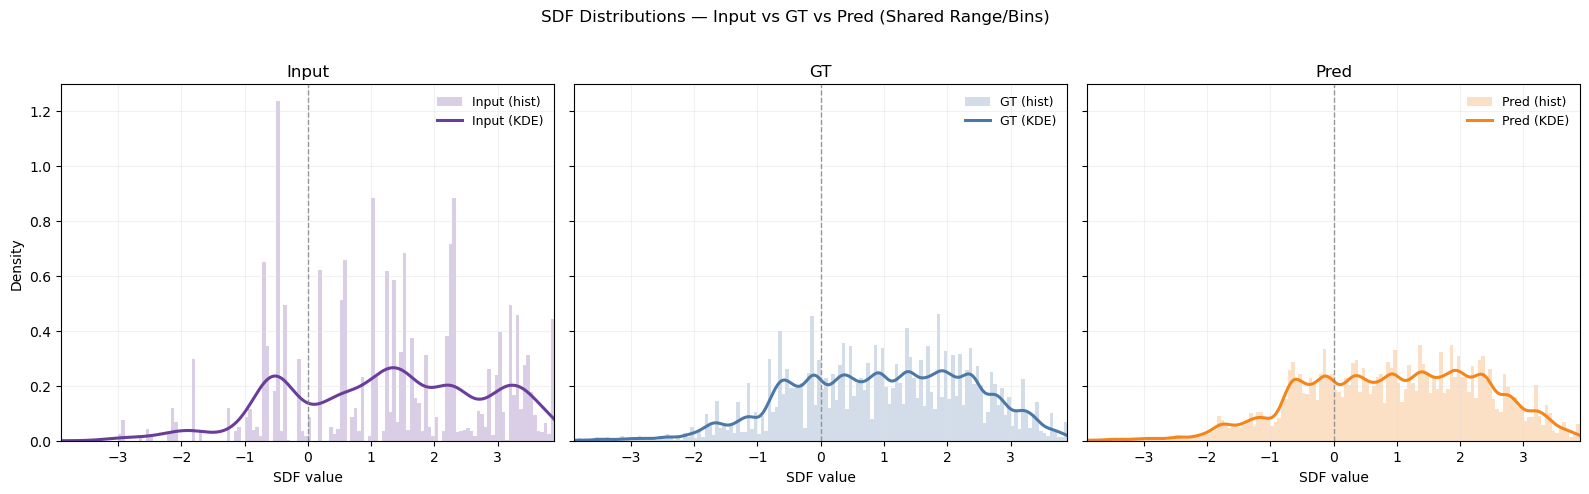

N (GT) = 236631 | N (Pred) = 236631 | N (Input×65) = 4680


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- Assume you've already computed these arrays ---
# act_sdf_val, pred_sdf_val, inp_sdf_val (input was scaled by 65 earlier)

gt   = np.asarray(act_sdf_val,  float).ravel()
pred = np.asarray(pred_sdf_val, float).ravel()
inp  = np.asarray(inp_sdf_val,  float).ravel()

# Clean invalids independently
gt   = gt[np.isfinite(gt)]
pred = pred[np.isfinite(pred)]
inp  = inp[np.isfinite(inp)]

# Colors (distinct per panel)
colors = {"gt":"#4C78A8", "pred":"#F58518", "inp":"#6A3D9A", "grid":"0.87"}

# Global symmetric range (trim tails so details show)
all_vals = np.concatenate([x for x in [gt, pred, inp] if x.size])
lo = np.percentile(all_vals, 0.5)
hi = np.percentile(all_vals, 99.5)
rng = max(abs(lo), abs(hi))
hist_range = (-rng, rng) if np.isfinite(rng) and rng > 0 else (
    -max(np.max(np.abs(all_vals)), 1.0), max(np.max(np.abs(all_vals)), 1.0)
)

# Adaptive bins (Freedman–Diaconis)
def fd_bins(a, vrange):
    a = a[(a >= vrange[0]) & (a <= vrange[1])]
    if a.size < 2:
        return 60
    iqr = np.subtract(*np.percentile(a, [75, 25]))
    if iqr == 0:
        return 200
    h = 2 * iqr / np.cbrt(a.size)
    return max(60, int(np.ceil((vrange[1] - vrange[0]) / h)))

bins = fd_bins(all_vals, hist_range)

# Smooth line helper: KDE if SciPy available; else Gaussian-smoothed hist
def smooth_line(ax, samples, vrange, bins, label, color):
    try:
        from scipy.stats import gaussian_kde
        xs = np.linspace(vrange[0], vrange[1], 1024)
        data = samples[(samples >= vrange[0]) & (samples <= vrange[1])]
        if data.size > 1:
            kde = gaussian_kde(data)
            ys = kde(xs)
            ax.plot(xs, ys, lw=2.2, color=color, label=f"{label} (KDE)")
    except Exception:
        counts, edges = np.histogram(samples, bins=bins, range=vrange, density=True)
        centers = 0.5*(edges[1:] + edges[:-1])
        sigma_bins = 1.8
        rad = int(np.ceil(3*sigma_bins))
        kx = np.arange(-rad, rad+1)
        k = np.exp(-(kx**2)/(2*sigma_bins**2)); k /= k.sum()
        smoothed = np.convolve(counts, k, mode="same")
        ax.plot(centers, smoothed, lw=2.2, color=color, label=f"{label} (smoothed)")

def draw_panel(ax, samples, label, color):
    if samples.size == 0:
        ax.text(0.5, 0.5, f"No data: {label}", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    ax.hist(samples, bins=bins, range=hist_range, density=True,
            alpha=0.25, color=color, edgecolor="none", label=f"{label} (hist)")
    smooth_line(ax, samples, hist_range, bins, label, color)
    ax.axvline(0, ls="--", lw=1, color="0.5", alpha=0.8)
    ax.set_xlim(hist_range)
    ax.grid(True, alpha=0.4, color=colors["grid"])
    ax.set_title(label)
    ax.legend(frameon=False, fontsize=9)

# --- Side-by-side figure ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
draw_panel(axes[0], inp,  "Input",  colors["inp"])
draw_panel(axes[1], gt,   "GT",        colors["gt"])
draw_panel(axes[2], pred, "Pred",      colors["pred"])

# Labels on outer
axes[0].set_ylabel("Density")
for ax in axes:
    ax.set_xlabel("SDF value")

fig.suptitle("SDF Distributions — Input vs GT vs Pred (Shared Range/Bins)", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

print(f"N (GT) = {gt.size} | N (Pred) = {pred.size} | N (Input×65) = {inp.size}")


MAE=0.032221  RMSE=0.050549  Bias=-0.004604  N=236631
Near-surface (|SDF|<0.02): N=1902  RMSE=0.048519


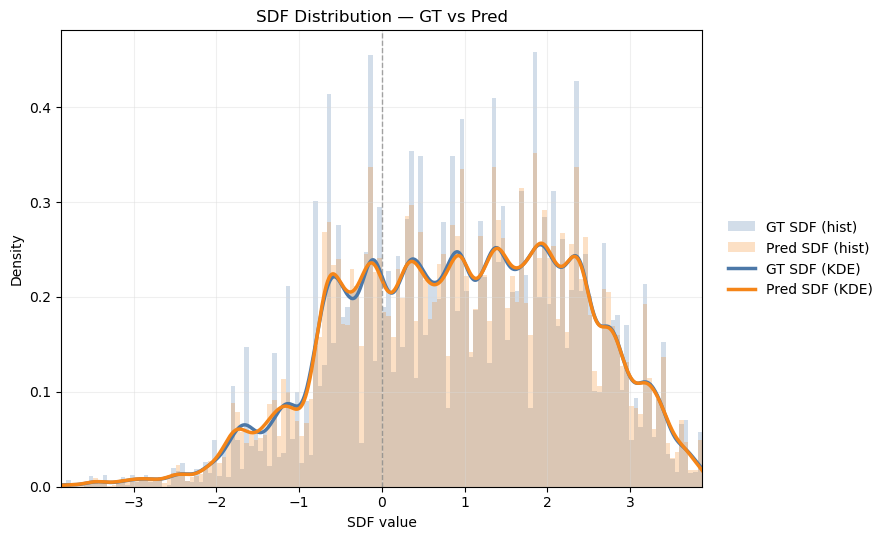

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


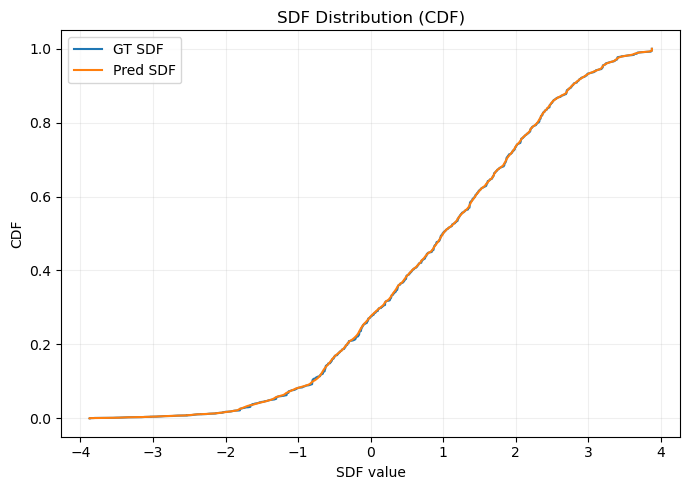

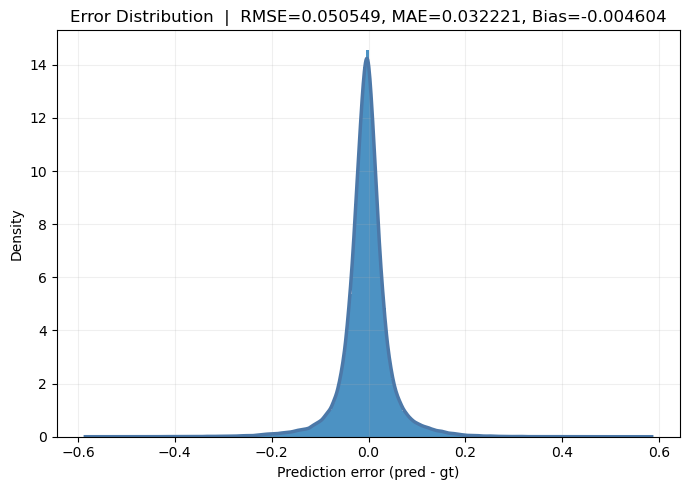

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


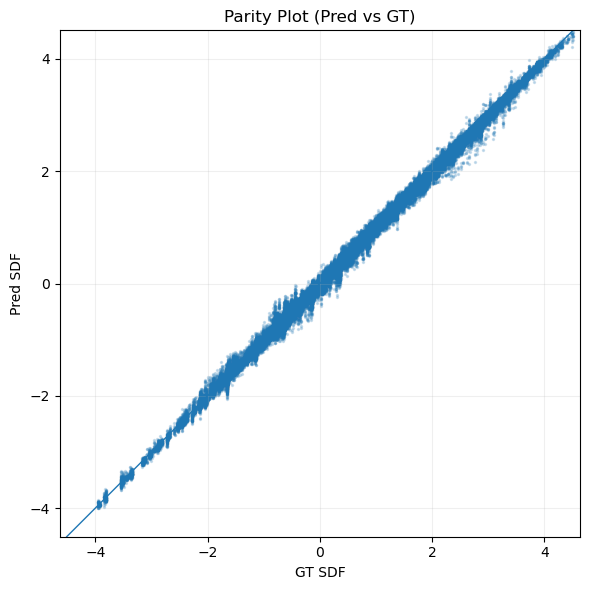

In [13]:
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns

# 0) Clean + common range
y = np.asarray(act_sdf_val).astype(float).ravel()
yhat = np.asarray(pred_sdf_val).astype(float).ravel()
inp  = np.asarray(inp_sdf_val,  float).ravel()

m = np.isfinite(y) & np.isfinite(yhat)
y, yhat = y[m], yhat[m]

# Common histogram range (symmetric if SDF)
rng = np.max(np.abs(np.concatenate([y, yhat]))) if y.size else 1.0
hist_range = (-rng, rng)

# 1) Summary stats
err = yhat - y
mae = np.mean(np.abs(err))
rmse = np.sqrt(np.mean(err**2))
bias = np.mean(err)
print(f"MAE={mae:.6f}  RMSE={rmse:.6f}  Bias={bias:.6f}  N={len(y)}")

# Near-surface mask (optional): focus on band around 0
band = 0.02  # 2 cm if units are meters; adjust as needed
ms = np.abs(y) < band
print(f"Near-surface (|SDF|<{band}): N={ms.sum()}  RMSE={np.sqrt(np.mean((yhat[ms]-y[ms])**2)):.6f}")


# --- pleasant colors (edit to taste)
colors = {
    "gt":   "#4C78A8",  # blue
    "pred": "#F58518",  # orange
    "grid": "0.85"
}

# --- trimmed symmetric range so tails don't crush detail
lo = np.percentile(np.concatenate([y, yhat]), 0.5)
hi = np.percentile(np.concatenate([y, yhat]), 99.5)
rng = max(abs(lo), abs(hi)) if np.isfinite([lo, hi]).all() else max(np.max(np.abs(y)), np.max(np.abs(yhat)))
hist_range = (-rng, rng)

# --- Freedman–Diaconis bins (adaptive)
def fd_bins(a, vrange):
    a = a[(a >= vrange[0]) & (a <= vrange[1])]
    if a.size < 2:
        return 60
    iqr = np.subtract(*np.percentile(a, [75, 25]))
    if iqr == 0:
        return 200
    h = 2 * iqr / np.cbrt(a.size)
    return max(60, int(np.ceil((vrange[1] - vrange[0]) / h)))

bins = fd_bins(np.concatenate([y, yhat]), hist_range)

# --- KDE if SciPy exists; else smooth histogram
def smooth_line(samples, vrange, bins, label, color):
    xs = None
    try:
        from scipy.stats import gaussian_kde
        xs = np.linspace(vrange[0], vrange[1], 1024)
        kde = gaussian_kde(samples[(samples >= vrange[0]) & (samples <= vrange[1])])
        ys = kde(xs)
        plt.plot(xs, ys, lw=2.5, color=color, label=f"{label} (KDE)")
    except Exception:
        counts, edges = np.histogram(samples, bins=bins, range=vrange, density=True)
        centers = 0.5 * (edges[1:] + edges[:-1])
        # simple Gaussian smoothing
        sigma_bins = 1.5
        rad = int(np.ceil(3 * sigma_bins))
        kx = np.arange(-rad, rad + 1)
        k = np.exp(-(kx**2) / (2 * sigma_bins**2))
        k = k / k.sum()
        smoothed = np.convolve(counts, k, mode="same")
        plt.plot(centers, smoothed, lw=2.5, color=color, label=f"{label} (smoothed)")

plt.figure(figsize=(9, 5.5))

# light histograms for context
plt.hist(y,    bins=bins, range=hist_range, density=True, alpha=0.25, color=colors["gt"],   edgecolor="none", label="GT SDF (hist)")
plt.hist(yhat, bins=bins, range=hist_range, density=True, alpha=0.25, color=colors["pred"], edgecolor="none", label="Pred SDF (hist)")

# smooth overlay lines
smooth_line(y,    hist_range, bins, "GT SDF",   colors["gt"])
smooth_line(yhat, hist_range, bins, "Pred SDF", colors["pred"])

# style & labels
plt.axvline(0, ls="--", lw=1, color="0.5", alpha=0.7)
plt.xlim(hist_range)
plt.xlabel("SDF value")
plt.ylabel("Density")
plt.title("SDF Distribution — GT vs Pred")
plt.grid(True, alpha=0.4, color=colors["grid"])
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

# 3) CDFs
def ecdf(a):
    a = np.sort(a)
    x = a
    y = np.linspace(0, 1, len(a), endpoint=True)
    return x, y

x1, F1 = ecdf(np.clip(y, *hist_range))
x2, F2 = ecdf(np.clip(yhat, *hist_range))
plt.figure(figsize=(7,5))
plt.plot(x1, F1, label="GT SDF")
plt.plot(x2, F2, label="Pred SDF")
plt.xlabel("SDF value")
plt.ylabel("CDF")
plt.title("SDF Distribution (CDF)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()

# 4) Error histogram
plt.figure(figsize=(7,5))
err_rng = np.max(np.abs(err)) if err.size else 1.0
plt.hist(err, bins=200, range=(-err_rng, err_rng), density=True, alpha=0.8)
plt.xlabel("Prediction error (pred - gt)")
plt.ylabel("Density")
plt.title(f"Error Distribution  |  RMSE={rmse:.6f}, MAE={mae:.6f}, Bias={bias:.6f}")
bins=200
hist_range=(-err_rng, err_rng)
smooth_line(err,    hist_range, bins, "pred error",   colors["gt"])
plt.grid(True, alpha=0.2)
plt.tight_layout()

# 5) Parity plot (ŷ vs y)
plt.figure(figsize=(6,6))
# sample if huge
idx = np.random.choice(len(y), size=min(200000, len(y)), replace=False) if len(y) > 200000 else slice(None)
ys, yhats = y[idx], yhat[idx]
lim = max(np.max(np.abs(ys)), np.max(np.abs(yhats)))
plt.scatter(ys, yhats, s=2, alpha=0.2)
plt.plot([-lim, lim], [-lim, lim], lw=1)
plt.xlabel("GT SDF")
plt.ylabel("Pred SDF")
plt.title("Parity Plot (Pred vs GT)")
plt.axis("equal")
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()


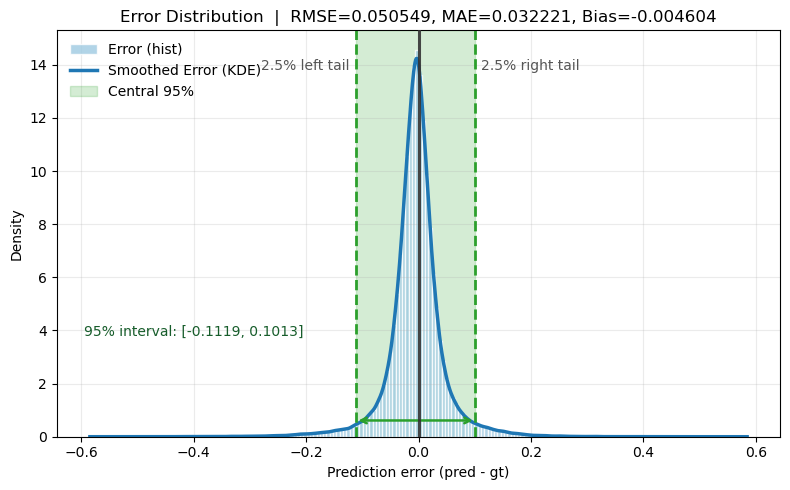

In [14]:
# 95% central interval via quantiles
p_lo, p_hi = np.quantile(err, [0.025, 0.975])
inside     = np.mean((err >= p_lo) & (err <= p_hi))
left_tail  = np.mean(err < p_lo)
right_tail = np.mean(err > p_hi)

# Range/bins (keep your style)
err_rng = np.max(np.abs(err)) if err.size else 1.0
bins = 200
hist_range = (-err_rng, err_rng)

# Accent color for the 95% interval
accent = "#2ca02c"  # pleasant green
# ... keep all your existing code above ...

plt.figure(figsize=(8,5))
counts, edges, _ = plt.hist(
    err, bins=bins, range=hist_range, density=True,
    alpha=0.8, color="#9ecae1", edgecolor="white", label="Error (hist)"
)

# Smooth overlay
try:
    smooth_line(err, hist_range, bins, "Smoothed Error", "#1f77b4")
except Exception:
    pass

# Shade the central 95%
plt.axvspan(p_lo, p_hi, color=accent, alpha=0.20, zorder=0, label="Central 95%")
plt.axvline(p_lo, color=accent, ls="--", lw=2)
plt.axvline(p_hi, color=accent, ls="--", lw=2)

ax = plt.gca()
ymin, ymax = ax.get_ylim()
y = ymin + 0.04*(ymax - ymin)

# Pretty bracket + label
ax.annotate("", xy=(p_lo, y), xytext=(p_hi, y),
            arrowprops=dict(arrowstyle="<->", lw=1.8, color=accent), annotation_clip=False)
ax.text((-0.4 ), y + 0.2*(ymax - ymin),
        f"95% interval: [{p_lo:.4g}, {p_hi:.4g}]",
        ha="center", va="bottom", fontsize=10, color="#175d2b")

# Tail annotations
ax.text(p_lo-0.01, ymax*0.93, f"{left_tail*100:.1f}% left tail",  ha="right", va="top", color="#555")
ax.text(p_hi+0.01, ymax*0.93, f"{right_tail*100:.1f}% right tail", ha="left",  va="top", color="#555")

# ==== ORIGIN MARKER (x = 0) ====
ax.axvline(0, color="#333333", lw=2.2, alpha=0.9, zorder=4)           # vertical origin
ax.text(0, ymin + 0.06*(ymax - ymin), "", ha="center", va="bottom",   # subtle label
        fontsize=9, color="#333333", bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
# (Optional) emphasize baseline at density=0:
# ax.axhline(0, color="0.5", lw=1, alpha=0.7, zorder=3)

plt.xlabel("Prediction error (pred - gt)")
plt.ylabel("Density")
plt.title(f"Error Distribution  |  RMSE={rmse:.6f}, MAE={mae:.6f}, Bias={bias:.6f}")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


In [15]:
# import numpy as np
# from scipy import stats

# # pred, gt: 1D numpy arrays at the same locations (near-surface samples)
# pred = np.asarray(pred, float).ravel()
# gt   = np.asarray(gt,   float).ravel()

# m = np.isfinite(pred) & np.isfinite(gt)
# pred, gt = pred[m], gt[m]
# if pred.size == 0:
#     raise ValueError("No valid paired samples.")

# # 1) Wilcoxon signed-rank on differences (bias)
# d = pred - gt
# wilc_bias = stats.wilcoxon(d, zero_method="wilcox", alternative="two-sided", method="auto")

# # 2) Wilcoxon on absolute distances (spread toward 0)
# da = np.abs(pred) - np.abs(gt)
# wilc_abs = stats.wilcoxon(da, zero_method="wilcox", alternative="two-sided", method="auto")

# # 3) McNemar on inside/outside (sign<0)
# pred_in  = pred < 0
# gt_in    = gt   < 0
# # Discordant pairs
# n10 = np.sum((pred_in == 1) & (gt_in == 0))  # Pred inside, GT outside
# n01 = np.sum((pred_in == 0) & (gt_in == 1))  # Pred outside, GT inside
# # Exact binomial form of McNemar test:
# mcnemar_p = stats.binomtest(min(n01, n10), n01 + n10, 0.5, alternative="two-sided").pvalue

# # 4) Paired permutation test with Wasserstein-1 as the statistic
# def wasserstein_pred_gt(a, b):
#     return stats.wasserstein_distance(a, b)

# obs_T = wasserstein_pred_gt(pred, gt)

# rng = np.random.default_rng(42)
# n_perm = 5000  # adjust if needed
# T_perm = np.empty(n_perm, dtype=float)

# # Swap-within-pair permutations preserve pairing
# for k in range(n_perm):
#     swap = rng.integers(0, 2, size=pred.size, dtype=bool)
#     a = np.where(swap, gt,   pred)  # swapped preds
#     b = np.where(swap, pred, gt)    # swapped gts
#     T_perm[k] = wasserstein_pred_gt(a, b)

# p_perm = (np.sum(T_perm >= obs_T) + 1) / (n_perm + 1)

# # ------------ Pretty summary ------------
# def q(a, p): return np.quantile(a, p)
# summary = {
#     "N": int(pred.size),
#     "Bias Wilcoxon p": float(wilc_bias.pvalue),
#     "Median diff (Pred-GT)": float(np.median(d)),
#     "Abs-dist Wilcoxon p": float(wilc_abs.pvalue),
#     "Median |Pred|-|GT|": float(np.median(da)),
#     "Inside rate Pred": float(np.mean(pred_in)),
#     "Inside rate GT": float(np.mean(gt_in)),
#     "McNemar p (inside rate equal)": float(mcnemar_p),
#     "Wasserstein-1": float(obs_T),
#     "Paired permutation p (W1)": float(p_perm),
#     "Pred Q50/Q95": (float(q(pred,0.5)), float(q(pred,0.95))),
#     "GT   Q50/Q95": (float(q(gt,  0.5)), float(q(gt,  0.95))),
# }
# for k,v in summary.items():
#     print(f"{k}: {v}")


In [16]:
pred.sum(),gt.sum()

(np.float64(228402.95273194346), np.float64(229492.4885717996))

In [17]:
import numpy as np
from scipy import stats

# pred, gt are paired 1D arrays (near-surface)
pred = np.asarray(pred, float).ravel()
gt   = np.asarray(gt,   float).ravel()
m = np.isfinite(pred) & np.isfinite(gt)
pred, gt = pred[m], gt[m]

# 1) Pearson (linear)
pearson_r, pearson_p = stats.pearsonr(pred, gt)

# Simple calibration fit: Pred ~ a + b*GT (via least squares)
A = np.vstack([gt, np.ones_like(gt)]).T
b_slope, a_intercept = np.linalg.lstsq(A, pred, rcond=None)[0]
# R^2 of this linear fit
pred_lin = a_intercept + b_slope*gt
ss_res = np.sum((pred - pred_lin)**2)
ss_tot = np.sum((pred - np.mean(pred))**2)
r2 = 1 - ss_res/ss_tot

# 2) Spearman (rank/monotonic)
spearman_rho, spearman_p = stats.spearmanr(pred, gt)

# 3) Kendall tau (rank)
kendall_tau, kendall_p = stats.kendalltau(pred, gt, method="auto")

# 4) Distance correlation (subsample to keep it fast)
def distance_correlation(x, y):
    # Randomly sample 100 points
    n = len(x)
    if n > 1000:
        idx = np.random.choice(n, size=100, replace=False)
        x = x[idx]
        y = y[idx]
    x = x[:, None]; y = y[:, None]
    # Pairwise distances
    a = np.sqrt((x - x.T)**2)
    b = np.sqrt((y - y.T)**2)
    # Double-center
    A = a - a.mean(axis=0)[None,:] - a.mean(axis=1)[:,None] + a.mean()
    B = b - b.mean(axis=0)[None,:] - b.mean(axis=1)[:,None] + b.mean()
    dCov2 = (A*B).mean()
    dVarX = (A*A).mean()
    dVarY = (B*B).mean()
    return np.sqrt(dCov2 / np.sqrt(dVarX*dVarY + 1e-12) + 1e-18)

n = pred.size
rng = np.random.default_rng(0)
n_sub = min(20000, n)   # adjust if you can afford more
idx = rng.choice(n, size=n_sub, replace=False)
dcor = float(distance_correlation(pred[idx], gt[idx]))

# (Optional) permutation p-value for dCor
n_perm = 1000
T_perm = np.empty(n_perm, float)
for k in range(n_perm):
    T_perm[k] = distance_correlation(pred[idx], rng.permutation(gt[idx]))
dcor_p = (np.sum(T_perm >= dcor) + 1) / (n_perm + 1)

# ---------- Print a compact summary ----------
def strength(x):
    # rough guide; adjust to your domain
    return "weak" if x < 0.3 else "moderate" if x < 0.7 else "strong"

print(f"Pearson r = {pearson_r:.4f}  (p={pearson_p:.2e})   -> {strength(abs(pearson_r))} linear association")
print(f"  Linear calibration: slope b={b_slope:.4f}, intercept a={a_intercept:.4f}, R^2={r2:.4f}")
print(f"Spearman ρ = {spearman_rho:.4f}  (p={spearman_p:.2e}) -> {strength(abs(spearman_rho))} monotonic association")
print(f"Kendall τ  = {kendall_tau:.4f}  (p={kendall_p:.2e})   -> {strength(abs(kendall_tau))} concordance")
print(f"Distance corr = {dcor:.4f}  (perm p={dcor_p:.3f})    -> non-linear dependence measure")

Pearson r = 0.9994  (p=0.00e+00)   -> strong linear association
  Linear calibration: slope b=1.0011, intercept a=-0.0057, R^2=0.9987
Spearman ρ = 0.9993  (p=0.00e+00) -> strong monotonic association
Kendall τ  = 0.9803  (p=0.00e+00)   -> strong concordance
Distance corr = 0.9991  (perm p=0.001)    -> non-linear dependence measure


In [18]:
import numpy as np
from scipy import stats

# pred, gt are paired 1D arrays (near-surface)
pred = np.asarray(pred, float).ravel()
gt   = np.asarray(gt,   float).ravel()
m = np.isfinite(pred) & np.isfinite(gt)
pred, gt = pred[m], gt[m]

# 1) Pearson (linear)
pearson_r, pearson_p = stats.pearsonr(pred, gt)

# Simple calibration fit: Pred ~ a + b*GT (via least squares)
A = np.vstack([gt, np.ones_like(gt)]).T
b_slope, a_intercept = np.linalg.lstsq(A, pred, rcond=None)[0]
# R^2 of this linear fit
pred_lin = a_intercept + b_slope*gt
ss_res = np.sum((pred - pred_lin)**2)
ss_tot = np.sum((pred - np.mean(pred))**2)
r2 = 1 - ss_res/ss_tot

# 2) Spearman (rank/monotonic)
spearman_rho, spearman_p = stats.spearmanr(pred, gt)

# 3) Kendall tau (rank)
kendall_tau, kendall_p = stats.kendalltau(pred, gt, method="auto")

# 4) Distance correlation (subsample to keep it fast)
def distance_correlation(x, y):
    # Randomly sample 100 points
    n = len(x)
    if n > 1000:
        idx = np.random.choice(n, size=100, replace=False)
        x = x[idx]
        y = y[idx]
    x = x[:, None]; y = y[:, None]
    # Pairwise distances
    a = np.sqrt((x - x.T)**2)
    b = np.sqrt((y - y.T)**2)
    # Double-center
    A = a - a.mean(axis=0)[None,:] - a.mean(axis=1)[:,None] + a.mean()
    B = b - b.mean(axis=0)[None,:] - b.mean(axis=1)[:,None] + b.mean()
    dCov2 = (A*B).mean()
    dVarX = (A*A).mean()
    dVarY = (B*B).mean()
    return np.sqrt(dCov2 / np.sqrt(dVarX*dVarY + 1e-12) + 1e-18)

n = pred.size
rng = np.random.default_rng(0)
n_sub = min(20000, n)   # adjust if you can afford more
idx = rng.choice(n, size=n_sub, replace=False)
dcor = float(distance_correlation(pred[idx], gt[idx]))

# (Optional) permutation p-value for dCor
n_perm = 1000
T_perm = np.empty(n_perm, float)
for k in range(n_perm):
    T_perm[k] = distance_correlation(pred[idx], rng.permutation(gt[idx]))
dcor_p = (np.sum(T_perm >= dcor) + 1) / (n_perm + 1)

# ---------- Print a compact summary ----------
def strength(x):
    # rough guide; adjust to your domain
    return "weak" if x < 0.3 else "moderate" if x < 0.7 else "strong"

print(f"Pearson r = {pearson_r:.4f}  (p={pearson_p:.2e})   -> {strength(abs(pearson_r))} linear association")
print(f"  Linear calibration: slope b={b_slope:.4f}, intercept a={a_intercept:.4f}, R^2={r2:.4f}")
print(f"Spearman ρ = {spearman_rho:.4f}  (p={spearman_p:.2e}) -> {strength(abs(spearman_rho))} monotonic association")
print(f"Kendall τ  = {kendall_tau:.4f}  (p={kendall_p:.2e})   -> {strength(abs(kendall_tau))} concordance")
print(f"Distance corr = {dcor:.4f}  (perm p={dcor_p:.3f})    -> non-linear dependence measure")

Pearson r = 0.9994  (p=0.00e+00)   -> strong linear association
  Linear calibration: slope b=1.0011, intercept a=-0.0057, R^2=0.9987
Spearman ρ = 0.9993  (p=0.00e+00) -> strong monotonic association
Kendall τ  = 0.9803  (p=0.00e+00)   -> strong concordance
Distance corr = 0.9989  (perm p=0.001)    -> non-linear dependence measure


# Test with PoNQ

In [39]:
obj_names = ['00009954', '00009941', '00009956', '00009913', '00009982', '00009904']
path = '/data/workspaces/spanwar/results/ssu/test_predictions/58_just_rerun_55'
for obj_name in obj_names:
    org_obj_path = f"/data/workspaces/spanwar/dataset/preprocessing_nmc_data/abc_dataset_objs/{obj_name}/model.obj"
    org_mesh = trimesh.load(org_obj_path)
    plot(org_mesh.vertices, org_mesh.faces)
    grid, data, _ = fvdb.load(os.path.join(path, f'64_{obj_name}.nvdb'))
    plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5000640…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4997190…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5004816…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5004043…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 1.49…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5003022…